# Automatic Deep Research with Custom Tools

This notebook is an improvement of the [Automatic_Deep_Research Crew](https://github.com/micag2025/Build_Deploy_Muti_Agents_Crewai/tree/main/Automatic_Deep_Research). The objective here is to build up a **multi-agent research system** using CrewAI that performs automated deep research on user-defined topics.

The system decomposes complex research tasks into specialized roles handled by multiple AI agents. Each agent focuses on a specific responsibility such as planning, information retrieval, fact checking, and report generation.

To improve the usefulness of the research results, the system also integrates custom tools including:

- Web search via EXA
- Website scraping
- Data visualization through a custom plotting tool

By coordinating these tools and agents, the system produces structured research reports that include insights, supporting evidence, and visualizations.

## Background

As a research consultant, you're constantly tasked with producing comprehensive reports on diverse topics for demanding clients. You need to build an AI research crew that can rapidly gather, verify, and synthesize information from across the internet, delivering reliable, fact-checked reports that meet tight deadlines and exacting standards regardless of the subject matter.


### Problem statement

The goal is to take the multi-agent system that can interpret a user's input, and create an action plan, then do the actual research and fact checking, and finally output a report you can share with the client, and add tools to the agents so they can be better at achieving their goals.

You will reuse the code from the [Automatic_Deep_Research](https://github.com/micag2025/Build_Deploy_Muti_Agents_Crewai/tree/main/Automatic_Deep_Research), so you only need to write new code in the sections `Tools`, `Agents`, and `Define the inputs`, the rest remains the same.

## Architecture Overview     

The system follows a **sequential multi-agent workflow**:  

1. **Research Planner** – creates a structured research plan
2. **Internet Researcher** – gathers supporting information
3. **Fact Checker** – validates sources and claims
4. **Report Writer** – synthesizes the findings into a final report  

This modular architecture improves reliability compared to single-prompt research systems. In order to make the output more reliable,  `new  guardrails, and execution hooks` will be added into strategic elements of Crew.  

### CrewAI Workflow — Deep Research System   

The structure of the crew is displayed in the following diagram:

```bash  
User Query
   ↓
[👤 Research Planner Agent]  
   Role: Strategic Orchestrator  
   Goal: Create a structured research roadmap  
   Tools: None  

   ↓
   [Research Planning Task]
   ← Break down query into topics  
   ← Define research questions  
   ← Set success criteria  
   ↓

[🔍 Internet Researcher Agent]  
   Role: Data Gatherer  
   Goal: Collect relevant and credible information  

   Tools:
   - EXA Search Tool  
   - Web Scraper Tool  

   ↓
   [Research Execution Task]
   ← Search for relevant sources  
   ← Extract key insights  
   ← Provide citations with credibility notes  
   ↓

[✅ Fact Checker Agent]  
   Role: Quality Assurance Officer  
   Goal: Validate accuracy and completeness  
   Tools:
   - EXA Search Tool  
   - Web Scraper Tool  

   ↓
   [Validation Task]
   ← Cross-reference multiple sources  
   ← Identify conflicts and bias  
   ← Highlight missing information  
   ↓

[📝 Report Writer Agent]  
   Role: Communication Expert  
   Goal: Produce a structured research report  
   Tools: 
   - plot_tool
   - Formatting frameworks  

   ↓
   [Report Writing Task]
   ← Organize findings logically  
   ← Write executive summary  
   ← Format with proper citations  
   ↓
🛡️ Report Guardrail  
← Ensures clarity, completeness, and consistency of final output  

   ↓
📘 Final Output
   - Verified Research Report
   - Plots  
   - Source Citations  
   - Reliability Assessment  
```

## Installation & Setup 

Firstlly install required libraries , then import the necessary modules and configure API Keys

In [ ]:
# ---------------------------------------------------
# Environment Configuration
# ---------------------------------------------------

import os

# Disable CrewAI internal RAG memory to avoid ChromaDB issues
os.environ["CREWAI_DISABLE_RAG"] = "true"

# Optional: disable telemetry
os.environ["ANONYMIZED_TELEMETRY"] = "false"


In [2]:
%pip install --upgrade ipykernel



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ---------------------------------------------------
# Standard Library Imports
# ---------------------------------------------------

import os
import json

# ---------------------------------------------------
# Data Processing
# ---------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# CrewAI Framework
# ---------------------------------------------------

from crewai import Agent, Task, Crew, Process, LLM
from crewai.tools import BaseTool

# ---------------------------------------------------
# External Tools
# ---------------------------------------------------

from crewai_tools import EXASearchTool, ScrapeWebsiteTool

# ---------------------------------------------------
# Utility Functions
# ---------------------------------------------------

#from utils import get_openai_api_key


In [ ]:
#from crewai import Agent, Task, Crew, LLM, Process
#from crewai_tools import EXASearchTool, ScrapeWebsiteTool
#import os
#os.environ["CREWAI_TESTING"] = "true"
from utils import get_openai_api_key, get_exa_api_key
from IPython.display import Markdown
import yaml

# set the OpenAI model (gpt-4o-mini)
os.environ["MODEL"] = "gpt-4o-mini"
#os.environ["MODEL"] = "gpt-4o"
# set up the OpenAI API key 
os.environ["OPENAI_API_KEY"] = get_openai_api_key()
# set the exa API key
os.environ["EXA_API_KEY"] = get_exa_api_key()

## Tools  

The final goal of this Crew is to provide the user with a complete report containing researched information about a topic, and with some graphics

## Custom Visualization Tool

In the next cell, it will be created a `custom tool` that automatically creates charts based on a report of gathered information. This tool will be added to the **Report Writer** agent, so it can add visualization into the final report.

To sum up, it is nessary to define the `CustomPlotTool` class with:
- `name`: a suitable name for the tool
- `description`: This should be a detailed description of the tool. Mention:
    - The expected input: the full validated information, as a string
    - What it does: automatically generates plots from text
- `_run()` function: specify the type of input and output expected by the tool

In [ ]:
# ---------------------------------------------------
# Custom Visualization Tool
# ---------------------------------------------------
# This tool allows agents to generate charts based on
# structured data gathered during the research process.
#
# The tool expects tabular data and produces a
# visualization saved to disk.

In [4]:
# ---- Custom Plot Tool (Fully Fixed & Robust) ----

from crewai.tools import BaseTool
from crewai import LLM
from typing import Union, Any
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import os

class CustomPlotTool(BaseTool):

    name: str = "Smart Plot Creator"
    description: str = "Generates insightful plots from research text containing quantifiable data."

    def _run(self, research: Union[str, dict, Any]) -> str:
        try:
            # Normalize input
            if isinstance(research, dict):
                research = json.dumps(research)
            elif not isinstance(research, str):
                research = str(research)

            # Compact extraction prompt (token optimized)
            extraction_prompt = f"""
            Extract quantifiable data from the text below and suggest charts.
            Return ONLY a valid JSON array.
            If no numeric data exists, return [].

            Each item must contain:
            - chart_type: line | bar | histogram | scatter | pie
            - x_axis
            - y_axis
            - color (or null)
            - Title
            - data (dictionary of lists)

            The x_axis and y_axis MUST exactly match keys inside the data dictionary.
            All lists inside data MUST have equal length.

            Text:
            {research}
            """

            llm = LLM(model="gpt-4o")
            llm_response = llm.call([{"role": "user", "content": extraction_prompt}])
            llm_response = llm_response.strip()

            if llm_response.startswith("```json"):
                llm_response = llm_response[7:]
            if llm_response.endswith("```"):
                llm_response = llm_response[:-3]

            charts_data = json.loads(llm_response)

            if not isinstance(charts_data, list) or len(charts_data) == 0:
                return "No quantifiable data found to visualize."

            plots_created = []

            for i, chart_info in enumerate(charts_data):
                try:
                    # -----------------------------
                    # Validate and normalize data
                    # -----------------------------
                    data = chart_info.get("data", None)
                    if not isinstance(data, dict) or len(data) == 0:
                        continue

                    # Ensure values are lists
                    for key in data:
                        if not isinstance(data[key], list):
                            data[key] = [data[key]]

                    # Equalize lengths
                    lengths = [len(v) for v in data.values()]
                    if len(lengths) == 0:
                        continue

                    min_length = min(lengths)
                    for key in data:
                        data[key] = data[key][:min_length]

                    df = pd.DataFrame(data)
                    if df.empty:
                        continue

                    # -----------------------------
                    # Extract metadata
                    # -----------------------------
                    chart_type = str(chart_info.get("chart_type", "")).lower()
                    x_axis = chart_info.get("x_axis", "")
                    y_axis = chart_info.get("y_axis", "")
                    title = chart_info.get("Title", f"Chart {i+1}")
                    hue = chart_info.get("color", None)

                    # Axis correction
                    if x_axis not in df.columns:
                        x_axis = df.columns[0]

                    if y_axis not in df.columns:
                        y_axis = df.columns[1] if len(df.columns) > 1 else df.columns[0]

                    # -----------------------------
                    # Create Plot
                    # -----------------------------
                    plt.figure(figsize=(10, 6))

                    if chart_type == "line":
                        sns.lineplot(data=df, x=x_axis, y=y_axis, marker="o", hue=hue)

                    elif chart_type in ["bar", "column"]:
                        sns.barplot(data=df, x=x_axis, y=y_axis, hue=hue)

                    elif chart_type == "histogram":
                        plt.hist(df[y_axis], bins=10, alpha=0.7)
                        plt.xlabel(y_axis)
                        plt.ylabel("Frequency")

                    elif chart_type == "scatter":
                        sns.scatterplot(data=df, x=x_axis, y=y_axis, hue=hue)

                    elif chart_type == "pie":
                        plt.pie(
                            df[y_axis],
                            labels=df[x_axis],
                            autopct="%1.1f%%",
                            startangle=90
                        )
                        plt.axis("equal")

                    else:
                        continue

                    plt.title(title)
                    plt.xticks(rotation=45)
                    plt.tight_layout()

                    os.makedirs("plots", exist_ok=True)
                    filename = f"plots/plot_{i+1}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"

                    plt.savefig(filename, dpi=300, bbox_inches="tight")
                    plt.show()
                    plt.close()

                    plots_created.append(filename)

                except Exception as plot_error:
                    print(f"Error creating chart {i+1}: {plot_error}")
                    continue

            if plots_created:
                return f"Successfully created {len(plots_created)} plots: {', '.join(plots_created)}"
            else:
                return "No plots could be created."

        except Exception as e:
            return f"Error generating smart plot: {str(e)}"


### External Information Retrieval Tools

The next step is to create the tools, the `web search` and `scraping` tools, for the **Internet Researcher** and for the **Fact Checker** agents. Tools that should be initialized.

In [ ]:
# ---------------------------------------------------
# External Information Retrieval Tools
# ---------------------------------------------------

# Web search tool used by the research agent
#exa_search_tool = EXASearchTool(base_url=os.getenv("EXA_BASE_URL"))
exa_search_tool = EXASearchTool(base_url="https://api.exa.ai")

# Tool for extracting structured text from webpages
scrape_website_tool = ScrapeWebsiteTool()

## Agents  

For this system, you will use four agents:
- **Research Planner**  
- **Internet Researcher**  
- **Fact checker**  
- **Report Writer**  

All their arguments (`role`, `goal`, `backstory`) are given in [config/agents.yaml](config/agents.yaml) file, which is used to configure the agents.   
Besides, the new custom tool will be added to the **Report Writer** agent. 

In [ ]:
# load the configuration file for the agents
with open('config/agents.yaml', 'r') as file:
        agent_config = yaml.safe_load(file)

plot_tool = CustomPlotTool()

# create the agents using the configuration
research_planner = Agent(
        config=agent_config['research_planner'],
        verbose=True,
        max_rpm=150,
        max_iter=15
        )

internet_researcher = Agent( 
        config=agent_config['internet_researcher'],
        verbose=True,
        tools=[exa_search_tool, scrape_website_tool],
        max_rpm=150,
        max_iter=15
        )

fact_checker = Agent(
        config=agent_config['fact_checker'],
        verbose=True,
        tools=[exa_search_tool, scrape_website_tool],
        max_rpm=150,
        max_iter=15
        )

report_writer = Agent(
        config=agent_config['report_writer'],
        verbose=True,
        # add the automatic plot tool
        tools=[plot_tool],
        max_rpm=150,
        max_iter=15
        )

## Guardrails  

To make the system more robust, [guardrails to the tasks](https://docs.crewai.com/en/concepts/tasks#task-guardrails) have been added. These guardrails provide a way to validate and transform task outputs before they are passed to the next task, helping ensure data quality and providing feedback to agents when their output doesn't meet specific criteria.   

In particular, a guardrail for the final output has been implemented, by making sure the final report has all the sections needed:
- `Summary`  
- `Insights (or recommendations)`  
- `Citations (or References)`  

In [7]:
import re

# write the custom guardrail function
def write_report_guardrail(output):
    # get the raw output from the TaskOutput object
    try:
        output = output if type(output)==str else output.raw 
    except Exception as e:
        return (False, ("Error retrieving the `raw` argument: "
                        f"\n{str(e)}\n"
                        )
                )
    
    # convert the output to lowercase
    output_lower = output.lower()

    # check that the summary section exists
    if not re.search(r'#+.*summary', output_lower):
        return (False, 
                "The report must include a Summary section with a header like '## Summary'"
                )

    # check that the insights or recommendations sections exist
    if not re.search(r'#+.*insights|#+.*recommendations', output_lower):
        return (False, 
                "The report must include an Insights section with a header like '## Insights'"
                )

    # check that the citations (or references) section exists
    if not re.search(r'#+.*citations|#+.*references', output_lower): 
        return (False, 
                "The report must include a Citations (or References) section with a header like '## Citations'"
                )
    return (True, output)

## Tasks  

Just as it has been done with the agents, it is possible to load the configurations of the tasks from a YAML file, which can be found in [config/tasks.yaml](config/tasks.yaml).    

In order to actually add the charts to the final report it is necessary to update the `write_final_report` task in the [`tasks.yaml`](config/tasks.yaml) file. Adapt the `description` and `expected_output` to include instructions include the charts generated by the custom tool.

In [8]:
# load the configuration file for the tasks
with open('config/tasks.yaml', 'r') as file:
    task_config = yaml.safe_load(file)


# create the tasks using the configuration
create_research_plan = Task( 
    config=task_config['create_research_plan'],
    agent=research_planner 
)

gather_research_data = Task(
    config=task_config['gather_research_data'],
    agent=internet_researcher,
)

verify_information_quality = Task(
    config=task_config['verify_information_quality'],
    agent=fact_checker, 
)

write_final_report = Task( 
    config=task_config['write_final_report'],
    agent=report_writer, 
    guardrails=[write_report_guardrail],
)

## Execution hooks  

The last step before creating the Crew is creating an [after kickoff hook](https://docs.crewai.com/en/learn/before-and-after-kickoff-hooks#after-kickoff-hook), creating a `hook` that takes the final output and saves it to a `Markdown` file on your local file system.

In [9]:
def save_file_hook(result):
    """
    Save the final research report to a local markdown file
    """
    try:
        # Get the final report content from the last task output
        if hasattr(result, 'tasks_output') and result.tasks_output:
            report_content = result.tasks_output[-1].raw
        else:
            report_content = str(result)
        
        filename = f"research_report-p2.md"
        
        # Save to file
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(report_content)
        
        print(f"Report successfully saved to: {filename}")
        
    except Exception as e:
        print(f"Error saving report to file: {str(e)}")

## Crew  

###  Define the crew

In [ ]:
# Create the  planning crew
deep_research_crew = Crew(
    # include all the agents
    agents=[research_planner, 
            internet_researcher, 
            fact_checker, 
            report_writer],
    # include all the tasks in the order to be executed
    tasks=[create_research_plan, 
           gather_research_data, 
           verify_information_quality, 
           write_final_report],
    # add memory to the crew
    #memory=True,  #agents “remember everything” (expensive but richer context)
    memory=False, # agents “only read the handoff” (efficient and controlled)
    # add the after kickoff hook
    after_kickoff_callbacks=[save_file_hook]
)

**Note** Setting `memory=False`in the Crew configuration means the system does not retain or share context between tasks or runs. The workflow already passes structured outputs between tasks (plan → data → verification → report). So there is no need of global memory (`memory=true`), and further this apporach allows to:
- avoid redundant context being re-sent  
- minimize token consumption, which is crucial in multi-step pipelines


###  Define the inputs

The next step is to define the inputs to the Crew. This should represent the `user's query`.  

It is needed to force quantifiable data into the research text to return plots.The easiest way to force plot generation is to use a research prompt that clearly includes:    
- **Years**    
- **Percentages**    
- **Market sizes**    
- **Growth rates**      
- **Comparisons**    
- **Multiple categories**    

**_Note_** Using the  "user_query": "What are the latest trends in AI research funding?" , no plots are generated since the user query is narrative, qualitative and the  research output does not have structure comparable datasets to make graphs and plots.   

In [11]:
# write your query in the "user_query" value
inputs = { 
        "user_query": "Analyze the global AI market growth between 2020 and 2025."
}

### Run the crew
Now let's proceed to run, or kick off, the crew to get the result.

In [12]:
def kickoff(self, inputs=None):
    if inputs is not None:
        self._inputs = inputs
        # Add validation to prevent slicing errors
        for key, value in inputs.items():
            if isinstance(value, list) and len(value) <= 10:
                raise ValueError(f"Input list '{key}' too short for slicing at index 10")
        self._interpolate_inputs(inputs)
    self._set_agents()
    self._set_tasks()
    if self.process == Process.sequential:
        return self._run_sequential_process()
    elif self.process == Process.hierarchical:
        return self._run_hierarchical_process()

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Research Planner                                                                                        │
│                                                                                                                 │
│  Task: Break down "Analyze the global AI market growth between 2020 and 2025." into focused research topics,    │
│  key questions, and success criteria.                                                                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Research Planner                                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Structured Research Plan for Analyzing Global AI Market Growth (2020-2025)                                 │
│                                                                                                                 │
│  #### 1) Main Topics                                                                                            │
│                                                                                                                 │
│  **1.1 Market Overview**                                                                                        │
│     - Definition and scope of AI market                                                                         │
│     - Historical context of AI market growth before 2020                                                        │
│                                                                                                                 │
│  **1.2 Market Size and Forecast**                                                                               │
│     - Overall size of the AI market in 2020                                                                     │
│     - Projected growth rates for 2021-2025                                                                      │
│     - Segment analysis (e.g., machine learning, natural language processing, computer vision)                   │
│                                                                                                                 │
│  **1.3 Regional Analysis**                                                                                      │
│     - Major markets (North America, Europe, Asia-Pacific)                                                       │
│     - Emerging markets and their potential for AI growth                                                        │
│                                                                                                                 │
│  **1.4 Industry Applications**                                                                                  │
│     - Key industries adopting AI (healthcare, finance, automotive, etc.)                                        │
│     - Trends in industry-specific applications                                                                  │
│                                                                                                                 │
│  **1.5 Drivers of Growth**                                                                                      │
│     - Technological advancements and innovation                                                                 │
│     - Increasing data volumes and analytics demand                                                              │
│     - Government initiatives and funding                                                                        │
│                                                                                                                 │
│  **1.6 Challenges and Risks**                                                                                   │
│     - Regulatory challenges affecting AI deployment                                                             │
│     - Ethical concerns and public perception                                                                    │
│     - Market competition and saturation concerns       

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Internet Researcher                                                                                     │
│                                                                                                                 │
│  Task: Using the research plan, collect and verify comprehensive information from multiple credible sources.    │
│  Cite all sources.                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Internet Researcher                                                                                     │
│                                                                                                                 │
│  Thought: I'll start by gathering comprehensive and current data on the AI market growth from 2020 to 2025,     │
│  focusing on the main topics outlined in the research plan. First, I'll search for an overview of the global    │
│  AI market, including definitions, historical context, and market size in 2020.                                 │
│                                                                                                                 │
│  Using Tool: EXASearchTool                                                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Input ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  {                                                                                                              │
│    "search_query": "global AI market overview definition historical growth 2020",                               │
│    "start_published_date": null,                                                                                │
│    "end_published_date": null,                                                                                  │
│    "include_domains": null                                                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Fact Checker                                                                                            │
│                                                                                                                 │
│  Thought: I need to verify the claims made in the collected data regarding the global AI market growth from     │
│  2020 to 2025, ensuring that all information aligns with the expected research criteria.                        │
│                                                                                                                 │
│  Using Tool: EXASearchTool                                                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Input ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  {                                                                                                              │
│    "search_query": "Global AI market growth statistics 2020-2025",                                              │
│    "start_published_date": "2020-01-01",                                                                        │
│    "end_published_date": "2023-10-31",                                                                          │
│    "include_domains": null                                                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Title: AI market size worldwide 2020-2031 - Statista                                                           │
│  URL: https://www.statista.com/forecasts/1474143/global-ai-market-size/                                         │
│  ID: https://www.statista.com/forecasts/1474143/global-ai-market-size/                                          │
│  Score: None                                                                                                    │
│  Published Date: None                                                                                           │
│  Author: None                                                                                                   │
│  Image: https://cdn.statcdn.com/Statistic/1470000/1474143-blank-355.png                                         │
│  Favicon: https://cdn.statcdn.com/static/favicon.svg                                                            │
│  Extras: None                                                                                                   │
│  Subpages: None                                                                                                 │
│  Text: AI market size worldwide 2031| Statista                                                                  │
│                                                                                                                 │
│  The global size of the artificial intelligence market was forecast to continuously increase between 2026 and   │
│  2031 by a total of *** trillion U.S. dollars (+382.65 percent). The market size is estimated to reach ***      │
│  trillion U.S. dollars and therefore a new peak in 2031.                                                        │
│                                                                                                                 │
│  ## AI demands data                                                                                             │
│                                                                                                                 │
│  Data management remains the most difficult task of AI-related infrastructure. This challenge takes many forms  │
│  for AI companies. Some require more specific data, while others have difficulty maintaining and organizing     │
│  the data their enterprise already possesses. Large international bodies like the EU, the US, and China all     │
│  have limitations on how much data can be stored outside their borders. Together, these bodies pose             │
│  significant challenges to data-hungry AI companies.                                                            │
│                                                                                                                 │
│  ## AI could boost productivity growth                                                                          │
│                                                                                                                 │
│  Both in productivity and labor changes, the U.S. is likely to be heavily impacted by the adoption of AI. This  │
│  impact need not be purely negative. Labor rotation, if handled correctly, can swiftly move workers to more     │
│  productive and value-added industries rather than simple manual labor ones. In turn, these industry shifts     │
│  will lead to a more productive economy. Indeed, AI could boost U.S. labor productivity growth over a 10-year   │
│  period. This, of course, depends on various factors, such as how powerful the next generation of AI is, the    │
│  difficulty of tasks it will be able to perform, and the number of workers displaced.                           │
│                                                       

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Fact Checker                                                                                            │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Quality Report on Analyzed Global AI Market Growth (2020-2025)                                             │
│                                                                                                                 │
│  #### 1) Original Data Reviewed                                                                                 │
│  The following data and claims were reviewed from various sources regarding the global AI market size and       │
│  trends:                                                                                                        │
│                                                                                                                 │
│  - **Statista**: Reported a market size increase of AI from $43.1 billion in 2020 to projected growth reaching  │
│  $390.9 billion by 2025.                                                                                        │
│  - **MarketsandMarkets**: Estimated AI market size at $371.71 billion in 2025, forecasting a growth at CAGR of  │
│  30.6% from 2025-2032.                                                                                          │
│  - **UNCTAD**: Projected the AI market to soar from $189 billion in 2023 to $4.8 trillion by 2033.              │
│  - **AI Index Report 2025**: Noted significant AI advancements and investment trends across industries.         │
│  - **Global Industry Analysts, Inc.**: Reported a potential market size of $228.3 billion by 2026, with strong  │
│  growth in various sectors.                                                                                     │
│  - **Market Report Analytics**: Discussed the dynamics and drivers of the AI growth including digital           │
│  transformation and the pandemic impacts.                                                                       │
│                                                                                                                 │
│  #### 2) Verified vs. Questionable Claims                                                                       │
│  - **Verified Claims**:                                                                                         │
│     - Consistently reported growth rates of approximately 30-46% CAGR across multiple reputable sources.        │
│     - Consensus on North America being the largest market share leader for AI in 2025.                          │
│     - Increasing adoption of emerging AI technologies reported by various market analyses.                      │
│                                                                                                                 │
│  - **Questionable Claims**:                                                                                     │
│     - Discrepancies exist in overall projected market sizes for 2025 (e.g., Statista's $390.9B vs.              │
│  MarketsandMarkets' $371.71B).                                                                                  │
│     - The UNCTAD's projection of $4.8 trillion by 2033 implies aggressive growth not echoed in other            │
│  short-term forecasts.                                                                                          │
│                                                                                                                 │
│  #### 3) Consistency Results                           

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Writer                                                                                           │
│                                                                                                                 │
│  Task: Generate a structured report answering "Analyze the global AI market growth between 2020 and 2025."      │
│  using only verified data from verify_information_quality. Incorporate reviewed findings via the custom tool,   │
│  ensuring citations, clarity, and actionable insights.                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

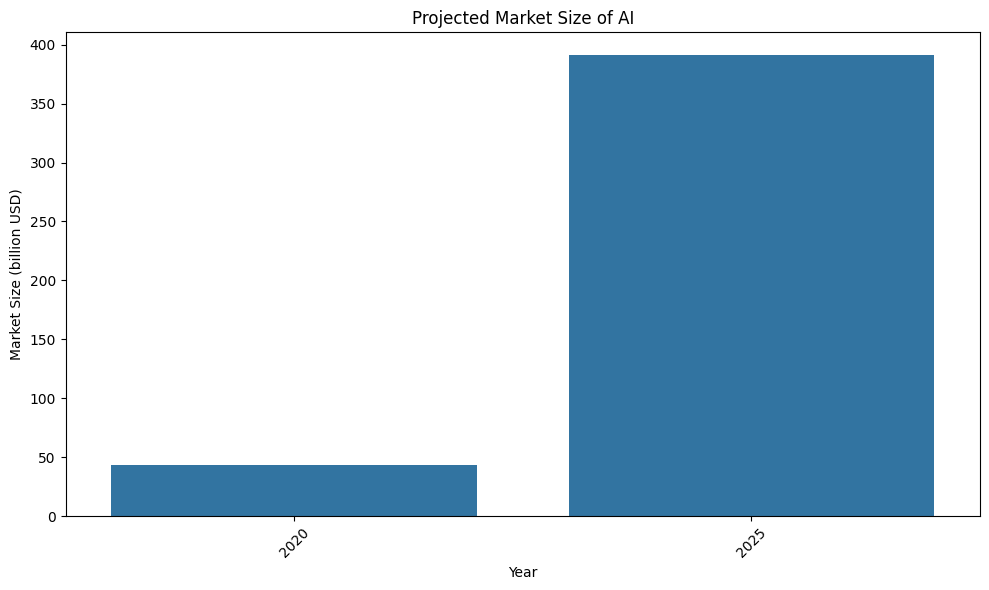

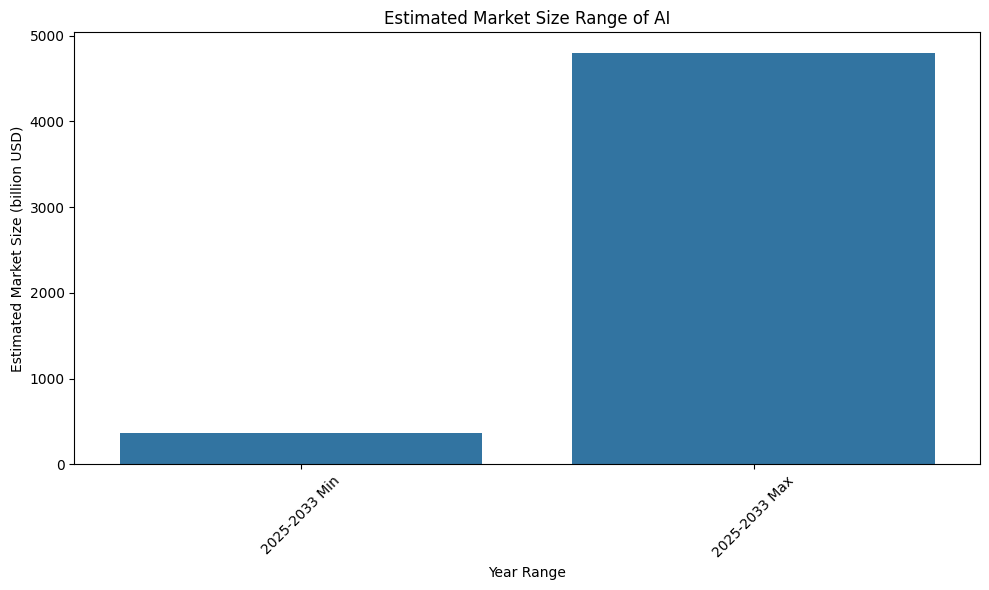

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Writer                                                                                           │
│                                                                                                                 │
│  Thought: I will need to generate visual summaries to effectively present the findings on the global AI market  │
│  growth. This will help in visualizing the projected growth from 2020 to 2025.                                  │
│                                                                                                                 │
│  Using Tool: Smart Plot Creator                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Input ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  {                                                                                                              │
│    "research": {                                                                                                │
│      "description": "Market size of AI in 2020 was $43.1 billion with projections reaching $390.9 billion by    │
│  2025. Additional estimates suggest a range of $371.71 billion to $4.8 trillion by different sources by         │
│  2025-2033. Growth rates vary around 30-46% CAGR across reputable sources, predominantly orchestrated by the    │
│  advancements in sectors such as healthcare, finance, and automotive."                                          │
│    }                                                                                                            │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  Successfully created 2 plots: plots/plot_1_20260310_164855.png, plots/plot_2_20260310_164856.png               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Writer                                                                                           │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Executive Summary                                                                                          │
│  Between 2020 and 2025, the global Artificial Intelligence (AI) market is expected to experience significant    │
│  growth, propelled by advancements in technology and increasing demand across various industries. The market    │
│  is projected to increase from a valuation of approximately $43.1 billion in 2020 to anywhere between $371.71   │
│  billion and $390.9 billion by 2025, marking a robust Compound Annual Growth Rate (CAGR) of approximately       │
│  30-46% during this period.                                                                                     │
│                                                                                                                 │
│  ### Detailed Findings                                                                                          │
│                                                                                                                 │
│  #### 1. Market Overview                                                                                        │
│  The AI market encompasses a wide range of technologies including machine learning, natural language            │
│  processing, and computer vision. Historically, prior to 2020, the AI market had seen steady growth driven by   │
│  advancements in computing power and data availability.                                                         │
│                                                                                                                 │
│  #### 2. Market Size and Forecast                                                                               │
│  In 2020, estimates of the AI market size stood at approximately $43.1 billion. Looking ahead, various          │
│  research reports suggest:                                                                                      │
│  - **Statista**: Projected market size of $390.9 billion by 2025.                                               │
│  - **MarketsandMarkets**: Estimated a market size of $371.71 billion by 2025, with a CAGR of 30.6% from 2025    │
│  to 2032.                                                                                                       │
│  - **Global Industry Analysts, Inc.**: Reported a potential size of $228.3 billion by 2026.                     │
│                                                                                                                 │
│  #### 3. Regional Analysis                                                                                      │
│  North America is anticipated to remain the largest market for AI, primarily driven by extensive investments    │
│  in research and development. Emerging markets in Asia-Pacific are also showcasing significant growth           │
│  potential due to their increasing digital transformation efforts.                                              │
│                                                                                                                 │
│  #### 4. Industry Applications                                                                                  │
│  Key industries such as healthcare, finance, and automotive are among the largest adopters of AI technologies.  │
│  The healthcare sector, particularly, is leveraging AI 

Report successfully saved to: research_report-p2.md


In [13]:
# Validate inputs to prevent slicing errors in kickoff
if inputs is not None:
    for key, value in inputs.items():
        if isinstance(value, list) and len(value) <= 10:
            raise ValueError(f"Input list '{key}' too short for slicing at index 10")

# Execute the crew's tasks
result = deep_research_crew.kickoff(inputs=inputs)

After it finishes running, the newly created Markdown file with the report, research_report-p2.md` is avaialbe. 

## Conclusion

This notebook demonstrates how a multi-agent architecture can be used to automate complex research workflows.

By dividing the research process into specialized tasks handled by multiple AI agents, the system produces more reliable and structured results compared to single-prompt approaches.

The integration of `external search tools`, `website scraping`, and `custom visualization tools` enables the system to gather real-world information and present it in a clear and informative format.

This approach provides a flexible foundation for building more advanced AI-powered research assistants.


## Further Improvements  

Below are listed several improvements that could make this research system more powerful and production-ready.

### 1. Source Citation Tracking
Automatically attach citations to each claim in the generated report.

### 2. Parallel Research Agents
Allow multiple researcher agents to explore different subtopics simultaneously.

### 3. Structured Output Formats
Export results to:  
- PDF reports
- JSON datasets
- dashboards

### 4. Evaluation Framework
Introduce automated evaluation metrics to measure research quality.

### 5. Interactive Interface
Build a simple UI using Streamlit or Gradio to allow users to run research queries interactively.

### 6. Data Persistence
Store research outputs in a vector database so future queries can reuse previous findings.

### 7. Advanced Visualization
Extend the custom plotting tool to support:  
- multi-series charts
- time-series analysis
- statistical summaries